In [ ]:
import pandas as pd

In [ ]:
# Install required libraries
!pip install transformers torch
!pip install spacy
!pip install keybert
!pip install pytesseract
!pip install pdfplumber
!pip install PyMuPDF  # Also known as fitz
!pip install docx2txt
!pip install opencv-python
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install nltk
!pip install scikit-learn

# Download spaCy language model
!python -m spacy download en_core_web_sm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# Core libraries for data manipulation and analysis
import pandas as pd
import numpy as np
import json
import os
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Document processing libraries
import fitz  # PyMuPDF for PDF processing
import pdfplumber
import docx2txt
import pytesseract
from PIL import Image
import cv2

# NLP libraries
import spacy
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM
from keybert import KeyBERT
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Download required NLTK data
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger')

# Configure matplotlib for better visualization
plt.style.use('default')
sns.set_palette("husl")

print("Environment setup completed successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


Environment setup completed successfully!


In [ ]:
# Initialize spaCy model for NER and linguistic analysis
try:
    nlp = spacy.load("en_core_web_sm")
    print("✓ spaCy English model loaded successfully")
except OSError:
    print("✗ spaCy English model not found. Please run: python -m spacy download en_core_web_sm")

# Initialize KeyBERT for keyword extraction
kw_model = KeyBERT()
print("✓ KeyBERT model initialized")

# Initialize summarization pipeline
try:
    summarizer = pipeline("summarization", model="facebook/bart-large-cnn")
    print("✓ Summarization model loaded successfully")
except Exception as e:
    print(f"✗ Error loading summarization model: {e}")
    summarizer = None

# Initialize sentiment analysis (optional)
try:
    sentiment_analyzer = pipeline("sentiment-analysis")
    print("✓ Sentiment analysis model loaded successfully")
except Exception as e:
    print(f"✗ Error loading sentiment analysis model: {e}")
    sentiment_analyzer = None

# Set up stopwords for text preprocessing
try:
    stop_words = set(stopwords.words('english'))
    print("✓ English stopwords loaded successfully")
except Exception as e:
    print(f"✗ Error loading stopwords: {e}")
    stop_words = set()

print("\nAll models initialized successfully!")


✓ spaCy English model loaded successfully


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


✓ Sentiment analysis model loaded successfully
✓ English stopwords loaded successfully

All models initialized successfully!


In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import tempfile

class DocumentUploader:
    def __init__(self):
        self.uploaded_files = {}
        self.supported_extensions = {'.pdf', '.docx', '.txt', '.png', '.jpg', '.jpeg'}

    def create_upload_interface(self):
        """Create interactive file upload interface"""

        # File upload widget
        self.uploader = widgets.FileUpload(
            accept='.pdf,.docx,.txt,.png,.jpg,.jpeg',
            multiple=True,
            description='Upload Files',
            style={'description_width': 'initial'}
        )

        # Upload button
        upload_btn = widgets.Button(
            description='Process Files',
            button_style='success',
            icon='upload'
        )

        # Output area
        self.output = widgets.Output()

        # Connect button to processing function
        upload_btn.on_click(self.process_uploaded_files)

        # Display interface
        display(widgets.VBox([
            widgets.HTML("<h3>📁 Document Upload Interface</h3>"),
            self.uploader,
            upload_btn,
            self.output
        ]))

    def process_uploaded_files(self, button):
        """Process uploaded files and validate them"""
        with self.output:
            clear_output()

            if not self.uploader.value:
                print("❌ No files uploaded. Please select files to process.")
                return

            print("🔄 Processing uploaded files...")
            processed_count = 0

            for filename, file_info in self.uploader.value.items():
                content = file_info['content']

                # Validate file extension
                file_ext = Path(filename).suffix.lower()
                if file_ext not in self.supported_extensions:
                    print(f"⚠️ Skipping unsupported file: {filename}")
                    continue

                # Save file temporarily
                temp_path = self.save_temp_file(filename, content)
                if temp_path:
                    self.uploaded_files[filename] = {
                        'path': temp_path,
                        'extension': file_ext,
                        'size': len(content)
                    }
                    processed_count += 1
                    print(f"✅ {filename} uploaded successfully")

            print(f"\n📊 Summary: {processed_count} files processed successfully")
            if self.uploaded_files:
                self.display_file_summary()

    def save_temp_file(self, filename, content):
        """Save uploaded file to temporary location"""
        try:
            temp_dir = tempfile.gettempdir()
            temp_path = os.path.join(temp_dir, filename)

            with open(temp_path, 'wb') as f:
                f.write(content)

            return temp_path
        except Exception as e:
            print(f"❌ Error saving {filename}: {e}")
            return None

    def display_file_summary(self):
        """Display summary of uploaded files"""
        print("\n📋 Uploaded Files Summary:")
        print("-" * 50)

        for filename, info in self.uploaded_files.items():
            size_mb = info['size'] / (1024 * 1024)
            print(f"📄 {filename}")
            print(f"   Type: {info['extension']}")
            print(f"   Size: {size_mb:.2f} MB")
            print(f"   Path: {info['path']}")
            print()

# Create and display upload interface
uploader = DocumentUploader()
uploader.create_upload_interface()


In [ ]:
def process_local_file(file_path):
    """Process a local file by path"""
    file_path = Path(file_path)

    if not file_path.exists():
        print(f"❌ File not found: {file_path}")
        return None

    file_ext = file_path.suffix.lower()
    supported_extensions = {'.pdf', '.docx', '.txt', '.png', '.jpg', '.jpeg'}

    if file_ext not in supported_extensions:
        print(f"❌ Unsupported file type: {file_ext}")
        return None

    file_info = {
        'name': file_path.name,
        'path': str(file_path),
        'extension': file_ext,
        'size': file_path.stat().st_size
    }

    print(f"✅ File loaded: {file_path.name}")
    print(f"   Type: {file_ext}")
    print(f"   Size: {file_info['size'] / (1024 * 1024):.2f} MB")

    return file_info

# Example usage:
# file_info = process_local_file("path/to/your/document.pdf")


In [ ]:
process_local_file("/content/The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf")

✅ File loaded: The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf
   Type: .pdf
   Size: 0.40 MB


{'name': 'The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf',
 'path': '/content/The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf',
 'extension': '.pdf',
 'size': 423146}

In [ ]:
class PDFTextExtractor:
    def __init__(self):
        self.extracted_metadata = {}

    def extract_with_pymupdf(self, pdf_path):
        """Extract text using PyMuPDF (fitz) library"""
        try:
            doc = fitz.open(pdf_path)
            text_content = []

            # Extract basic document metadata
            metadata = doc.metadata
            self.extracted_metadata = {
                'title': metadata.get('title', ''),
                'author': metadata.get('author', ''),
                'subject': metadata.get('subject', ''),
                'creator': metadata.get('creator', ''),
                'producer': metadata.get('producer', ''),
                'creation_date': metadata.get('creationDate', ''),
                'modification_date': metadata.get('modDate', ''),
                'page_count': doc.page_count
            }

            # Extract text from each page
            for page_num in range(doc.page_count):
                page = doc.load_page(page_num)
                text = page.get_text()
                if text.strip():
                    text_content.append(text)

            doc.close()
            return '\n'.join(text_content)

        except Exception as e:
            print(f"❌ PyMuPDF extraction failed: {e}")
            return ""

    def extract_with_pdfplumber(self, pdf_path):
        """Extract text using pdfplumber library"""
        try:
            text_content = []

            with pdfplumber.open(pdf_path) as pdf:
                for page in pdf.pages:
                    text = page.extract_text()
                    if text:
                        text_content.append(text)

            return '\n'.join(text_content)

        except Exception as e:
            print(f"❌ pdfplumber extraction failed: {e}")
            return ""

    def extract_pdf_text(self, pdf_path):
        """Extract text using both methods and return the best result"""
        print(f"🔄 Extracting text from PDF: {Path(pdf_path).name}")

        # Try PyMuPDF first
        pymupdf_text = self.extract_with_pymupdf(pdf_path)

        # Try pdfplumber as backup
        pdfplumber_text = self.extract_with_pdfplumber(pdf_path)

        # Use the method that extracted more text
        if len(pymupdf_text) > len(pdfplumber_text):
            selected_text = pymupdf_text
            method_used = "PyMuPDF"
        else:
            selected_text = pdfplumber_text
            method_used = "pdfplumber"

        print(f"✅ Text extracted using {method_used} ({len(selected_text)} characters)")

        return selected_text, self.extracted_metadata

# Initialize PDF extractor
pdf_extractor = PDFTextExtractor()


In [ ]:
class DOCXTextExtractor:
    def __init__(self):
        self.extracted_metadata = {}

    def extract_docx_text(self, docx_path):
        """Extract text from DOCX files using docx2txt"""
        try:
            print(f"🔄 Extracting text from DOCX: {Path(docx_path).name}")

            # Extract text content
            text = docx2txt.process(docx_path)

            # Get basic file information
            file_stats = os.stat(docx_path)
            self.extracted_metadata = {
                'file_size': file_stats.st_size,
                'creation_time': file_stats.st_ctime,
                'modification_time': file_stats.st_mtime,
                'word_count': len(text.split()) if text else 0,
                'character_count': len(text) if text else 0
            }

            if text:
                print(f"✅ Text extracted successfully ({len(text)} characters)")
            else:
                print("⚠️ No text found in DOCX file")

            return text, self.extracted_metadata

        except Exception as e:
            print(f"❌ DOCX extraction failed: {e}")
            return "", {}

# Initialize DOCX extractor
docx_extractor = DOCXTextExtractor()


In [ ]:
class OCRTextExtractor:
    def __init__(self):
        self.extracted_metadata = {}

    def preprocess_image(self, image_path):
        """Preprocess image for better OCR results"""
        try:
            # Read image
            image = cv2.imread(image_path)

            # Convert to grayscale
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            # Apply Gaussian blur
            blur = cv2.GaussianBlur(gray, (3, 3), 0)

            # Apply threshold
            thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

            # Morphological operations to remove noise
            kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
            opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)

            # Invert image
            processed_image = 255 - opening

            return processed_image

        except Exception as e:
            print(f"❌ Image preprocessing failed: {e}")
            return None

    def extract_ocr_text(self, image_path):
        """Extract text from images using OCR"""
        try:
            print(f"🔄 Performing OCR on: {Path(image_path).name}")

            # Preprocess image
            processed_image = self.preprocess_image(image_path)

            if processed_image is None:
                return "", {}

            # Configure OCR settings
            ocr_config = '--psm 6'  # Assume uniform block of text

            # Extract text
            text = pytesseract.image_to_string(processed_image, config=ocr_config, lang='eng')

            # Get image metadata
            with Image.open(image_path) as img:
                self.extracted_metadata = {
                    'image_size': img.size,
                    'image_mode': img.mode,
                    'image_format': img.format,
                    'character_count': len(text) if text else 0
                }

            if text.strip():
                print(f"✅ OCR completed successfully ({len(text)} characters)")
            else:
                print("⚠️ No text detected in image")

            return text, self.extracted_metadata

        except Exception as e:
            print(f"❌ OCR extraction failed: {e}")
            return "", {}

# Initialize OCR extractor
ocr_extractor = OCRTextExtractor()


In [ ]:
def extract_text_from_file(file_info):
    """Unified text extraction function for all supported file types"""

    if not file_info:
        return "", {}

    file_path = file_info['path']
    file_ext = file_info['extension']

    print(f"\n📄 Processing: {file_info['name']}")
    print(f"🔍 File type: {file_ext}")

    # Route to appropriate extractor based on file extension
    if file_ext == '.pdf':
        text, metadata = pdf_extractor.extract_pdf_text(file_path)
    elif file_ext == '.docx':
        text, metadata = docx_extractor.extract_docx_text(file_path)
    elif file_ext == '.txt':
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                text = f.read()
            metadata = {'character_count': len(text), 'word_count': len(text.split())}
            print(f"✅ Text file loaded successfully ({len(text)} characters)")
        except Exception as e:
            print(f"❌ Text file reading failed: {e}")
            text, metadata = "", {}
    elif file_ext in ['.png', '.jpg', '.jpeg']:
        text, metadata = ocr_extractor.extract_ocr_text(file_path)
    else:
        print(f"❌ Unsupported file type: {file_ext}")
        return "", {}

    # Add common metadata
    metadata['original_filename'] = file_info['name']
    metadata['file_extension'] = file_ext
    metadata['extraction_method'] = f"{file_ext[1:].upper()} processor"

    return text, metadata


In [ ]:
class TextPreprocessor:
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        # Add custom stopwords for document processing
        self.custom_stopwords = {
            'page', 'pages', 'document', 'file', 'pdf', 'docx', 'txt',
            'figure', 'table', 'section', 'chapter', 'appendix'
        }
        self.stop_words.update(self.custom_stopwords)

    def basic_cleaning(self, text):
        """Perform basic text cleaning operations"""
        if not text:
            return ""

        # Remove extra whitespaces and normalize line breaks
        text = re.sub(r'\s+', ' ', text)
        text = re.sub(r'\n+', '\n', text)

        # Remove or replace special characters
        text = re.sub(r'[^\w\s\.\,\!\?\;\:\-\(\)]', ' ', text)

        # Fix common OCR errors
        text = re.sub(r'\s+([\.!?])', r'\1', text)  # Fix spacing before punctuation
        text = re.sub(r'([\.!?])\s*([A-Z])', r'\1 \2', text)  # Fix spacing after punctuation

        # Remove excessive punctuation
        text = re.sub(r'[\.]{2,}', '.', text)
        text = re.sub(r'[!]{2,}', '!', text)
        text = re.sub(r'[?]{2,}', '?', text)

        return text.strip()

    def remove_noise(self, text):
        """Remove document-specific noise and artifacts"""
        if not text:
            return ""

        # Remove page numbers and headers/footers patterns
        text = re.sub(r'\bPage\s+\d+\b', '', text, flags=re.IGNORECASE)
        text = re.sub(r'\b\d+\s+of\s+\d+\b', '', text, flags=re.IGNORECASE)

        # Remove URL patterns
        text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)

        # Remove email patterns
        text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)

        # Remove excessive numbering patterns
        text = re.sub(r'^\s*\d+\.\s*', '', text, flags=re.MULTILINE)

        # Remove table-like structures (multiple tabs or excessive spaces)
        text = re.sub(r'\t+', ' ', text)
        text = re.sub(r' {3,}', ' ', text)

        return text

    def normalize_text(self, text):
        """Normalize text for consistent processing"""
        if not text:
            return ""

        # Convert to lowercase for consistency
        text = text.lower()

        # Expand contractions
        contractions = {
            "won't": "will not", "can't": "cannot", "n't": " not",
            "'re": " are", "'ve": " have", "'ll": " will",
            "'d": " would", "'m": " am"
        }

        for contraction, expansion in contractions.items():
            text = text.replace(contraction, expansion)

        # Normalize currency and number formats
        text = re.sub(r'\$\d+(?:,\d{3})*(?:\.\d{2})?', 'CURRENCY', text)
        text = re.sub(r'\b\d{4}\b', 'YEAR', text)  # Years
        text = re.sub(r'\b\d+(?:,\d{3})*(?:\.\d+)?\b', 'NUMBER', text)  # Other numbers

        return text

    def remove_stopwords(self, text):
        """Remove stopwords while preserving sentence structure"""
        if not text:
            return ""

        words = word_tokenize(text)
        filtered_words = [word for word in words if word.lower() not in self.stop_words and len(word) > 2]

        return ' '.join(filtered_words)

    def extract_sentences(self, text):
        """Extract and clean sentences from text"""
        if not text:
            return []

        sentences = sent_tokenize(text)

        # Filter sentences by length and content quality
        quality_sentences = []
        for sentence in sentences:
            # Skip very short or very long sentences
            if 10 <= len(sentence) <= 500:
                # Skip sentences with excessive numbers or special characters
                if len(re.findall(r'[a-zA-Z]', sentence)) > len(sentence) * 0.7:
                    quality_sentences.append(sentence.strip())

        return quality_sentences

    def preprocess_text(self, text, remove_stopwords=False, normalize=True):
        """Complete preprocessing pipeline"""
        if not text:
            return {"processed_text": "", "sentences": [], "word_count": 0}

        print("🔄 Preprocessing text...")

        # Apply cleaning pipeline
        processed_text = self.basic_cleaning(text)
        processed_text = self.remove_noise(processed_text)

        if normalize:
            processed_text = self.normalize_text(processed_text)

        # Extract sentences before removing stopwords
        sentences = self.extract_sentences(processed_text)

        if remove_stopwords:
            processed_text = self.remove_stopwords(processed_text)

        word_count = len(processed_text.split()) if processed_text else 0

        print(f"✅ Preprocessing completed:")
        print(f"   - Word count: {word_count}")
        print(f"   - Sentence count: {len(sentences)}")
        print(f"   - Character count: {len(processed_text)}")

        return {
            "processed_text": processed_text,
            "sentences": sentences,
            "word_count": word_count,
            "character_count": len(processed_text)
        }

# Initialize text preprocessor
text_preprocessor = TextPreprocessor()


In [ ]:
def assess_text_quality(original_text, processed_text):
    """Assess the quality of text extraction and preprocessing"""

    quality_metrics = {}

    # Basic statistics
    quality_metrics['original_length'] = len(original_text) if original_text else 0
    quality_metrics['processed_length'] = len(processed_text) if processed_text else 0
    quality_metrics['compression_ratio'] = (
        quality_metrics['processed_length'] / quality_metrics['original_length']
        if quality_metrics['original_length'] > 0 else 0
    )

    # Language detection and readability
    if processed_text:
        words = processed_text.split()
        quality_metrics['word_count'] = len(words)
        quality_metrics['avg_word_length'] = sum(len(word) for word in words) / len(words) if words else 0

        sentences = sent_tokenize(processed_text)
        quality_metrics['sentence_count'] = len(sentences)
        quality_metrics['avg_sentence_length'] = (
            sum(len(sentence.split()) for sentence in sentences) / len(sentences)
            if sentences else 0
        )

        # Content diversity
        unique_words = set(words)
        quality_metrics['vocabulary_diversity'] = len(unique_words) / len(words) if words else 0

        # Special character ratio
        special_chars = len(re.findall(r'[^a-zA-Z0-9\s]', processed_text))
        quality_metrics['special_char_ratio'] = special_chars / len(processed_text) if processed_text else 0

    return quality_metrics

def display_quality_report(quality_metrics):
    """Display text quality assessment report"""
    print("\n📊 Text Quality Assessment Report")
    print("=" * 40)
    print(f"Original text length: {quality_metrics['original_length']:,} characters")
    print(f"Processed text length: {quality_metrics['processed_length']:,} characters")
    print(f"Compression ratio: {quality_metrics['compression_ratio']:.2%}")

    if quality_metrics.get('word_count', 0) > 0:
        print(f"Word count: {quality_metrics['word_count']:,}")
        print(f"Sentence count: {quality_metrics['sentence_count']:,}")
        print(f"Average word length: {quality_metrics['avg_word_length']:.1f} characters")
        print(f"Average sentence length: {quality_metrics['avg_sentence_length']:.1f} words")
        print(f"Vocabulary diversity: {quality_metrics['vocabulary_diversity']:.2%}")
        print(f"Special character ratio: {quality_metrics['special_char_ratio']:.2%}")

        # Quality assessment
        if quality_metrics['vocabulary_diversity'] > 0.4:
            print("✅ High vocabulary diversity - good for analysis")
        elif quality_metrics['vocabulary_diversity'] > 0.2:
            print("⚠️ Moderate vocabulary diversity")
        else:
            print("❌ Low vocabulary diversity - may indicate poor extraction")


In [ ]:
class KeywordExtractor:
    def __init__(self):
        self.kw_model = KeyBERT()
        self.nlp = nlp  # spaCy model for linguistic features

    def extract_keywords_keybert(self, text, num_keywords=10, keyphrase_ngram_range=(1, 3)):
        """Extract keywords using KeyBERT with BERT embeddings"""
        if not text or len(text.strip()) < 50:
            return []

        try:
            print("🔄 Extracting keywords using KeyBERT...")

            # Configure KeyBERT parameters for optimal results
            keywords = self.kw_model.extract_keywords(
                text,
                keyphrase_ngram_range=keyphrase_ngram_range,
                stop_words='english',
                top_k=num_keywords,
                use_maxsum=True,  # Use Max Sum Distance for diversity
                nr_candidates=num_keywords * 3,  # Consider more candidates
                use_mmr=True,  # Use Maximal Marginal Relevance
                diversity=0.5  # Balance between relevance and diversity
            )

            # Format results with confidence scores
            formatted_keywords = []
            for keyword, score in keywords:
                formatted_keywords.append({
                    'keyword': keyword,
                    'confidence': round(score, 3),
                    'length': len(keyword.split())
                })

            print(f"✅ Extracted {len(formatted_keywords)} keywords")
            return formatted_keywords

        except Exception as e:
            print(f"❌ KeyBERT extraction failed: {e}")
            return []

    def extract_keywords_tfidf(self, text, num_keywords=10):
        """Extract keywords using TF-IDF as fallback method"""
        if not text:
            return []

        try:
            print("🔄 Extracting keywords using TF-IDF...")

            # Configure TF-IDF vectorizer
            vectorizer = TfidfVectorizer(
                max_features=1000,
                stop_words='english',
                ngram_range=(1, 3),
                max_df=0.85,
                min_df=2
            )

            # Handle single document by creating a small corpus
            sentences = sent_tokenize(text)
            if len(sentences) < 5:
                # If too few sentences, split by paragraphs
                sentences = [p.strip() for p in text.split('\n') if p.strip()]

            if len(sentences) < 2:
                return []

            # Fit and transform
            tfidf_matrix = vectorizer.fit_transform(sentences)
            feature_names = vectorizer.get_feature_names_out()

            # Get mean TF-IDF scores
            mean_scores = tfidf_matrix.mean(axis=0).A1

            # Create keyword list with scores
            keyword_scores = list(zip(feature_names, mean_scores))
            keyword_scores.sort(key=lambda x: x[1], reverse=True)

            # Format results
            formatted_keywords = []
            for keyword, score in keyword_scores[:num_keywords]:
                formatted_keywords.append({
                    'keyword': keyword,
                    'confidence': round(score, 3),
                    'length': len(keyword.split())
                })

            print(f"✅ Extracted {len(formatted_keywords)} TF-IDF keywords")
            return formatted_keywords

        except Exception as e:
            print(f"❌ TF-IDF extraction failed: {e}")
            return []

    def extract_keywords(self, text, method='keybert', num_keywords=10):
        """Extract keywords using specified method with fallback"""

        if method == 'keybert':
            keywords = self.extract_keywords_keybert(text, num_keywords)
            if not keywords:  # Fallback to TF-IDF if KeyBERT fails
                keywords = self.extract_keywords_tfidf(text, num_keywords)
        else:
            keywords = self.extract_keywords_tfidf(text, num_keywords)

        return keywords

# Initialize keyword extractor
keyword_extractor = KeywordExtractor()


In [ ]:
class NamedEntityExtractor:
    def __init__(self):
        self.nlp = nlp  # Pre-loaded spaCy model

        # Define entity categories of interest
        self.entity_categories = {
            'PERSON': 'People',
            'ORG': 'Organizations',
            'GPE': 'Geopolitical entities',
            'LOC': 'Locations',
            'DATE': 'Dates',
            'TIME': 'Times',
            'MONEY': 'Monetary values',
            'PERCENT': 'Percentages',
            'PRODUCT': 'Products',
            'EVENT': 'Events',
            'WORK_OF_ART': 'Works of art',
            'LAW': 'Laws and legal documents',
            'LANGUAGE': 'Languages'
        }

    def extract_entities(self, text, min_confidence=0.5):
        """Extract named entities with confidence filtering"""
        if not text:
            return {}

        try:
            print("🔄 Extracting named entities using spaCy...")

            # Process text with spaCy
            doc = self.nlp(text)

            # Group entities by type
            entities_by_type = {}

            for ent in doc.ents:
                entity_type = ent.label_
                entity_text = ent.text.strip()

                # Filter out single characters and very short entities
                if len(entity_text) < 2:
                    continue

                # Initialize category if not exists
                if entity_type not in entities_by_type:
                    entities_by_type[entity_type] = {}

                # Count entity occurrences
                if entity_text in entities_by_type[entity_type]:
                    entities_by_type[entity_type][entity_text]['count'] += 1
                else:
                    entities_by_type[entity_type][entity_text] = {
                        'count': 1,
                        'confidence': getattr(ent, 'confidence', 1.0),
                        'start_char': ent.start_char,
                        'end_char': ent.end_char
                    }

            # Format and filter results
            formatted_entities = {}
            for entity_type, entities in entities_by_type.items():
                if entity_type in self.entity_categories:
                    # Sort by count and take most frequent
                    sorted_entities = sorted(
                        entities.items(),
                        key=lambda x: x[1]['count'],
                        reverse=True
                    )

                    formatted_entities[entity_type] = {
                        'category_name': self.entity_categories[entity_type],
                        'entities': []
                    }

                    for entity_text, entity_info in sorted_entities[:10]:  # Top 10 per category
                        formatted_entities[entity_type]['entities'].append({
                            'text': entity_text,
                            'count': entity_info['count'],
                            'confidence': entity_info['confidence']
                        })

            total_entities = sum(len(cat['entities']) for cat in formatted_entities.values())
            print(f"✅ Extracted {total_entities} entities across {len(formatted_entities)} categories")

            return formatted_entities

        except Exception as e:
            print(f"❌ Named entity extraction failed: {e}")
            return {}

    def get_entity_summary(self, entities):
        """Generate summary statistics for extracted entities"""
        summary = {
            'total_categories': len(entities),
            'total_entities': 0,
            'most_common_type': None,
            'most_common_entity': None
        }

        all_entities = []
        category_counts = {}

        for entity_type, entity_data in entities.items():
            category_count = len(entity_data['entities'])
            category_counts[entity_type] = category_count
            summary['total_entities'] += category_count

            for entity in entity_data['entities']:
                all_entities.append((entity['text'], entity['count'], entity_type))

        if category_counts:
            summary['most_common_type'] = max(category_counts, key=category_counts.get)

        if all_entities:
            summary['most_common_entity'] = max(all_entities, key=lambda x: x[1])

        return summary

# Initialize named entity extractor
entity_extractor = NamedEntityExtractor()


In [ ]:
class TextSummarizer:
    def __init__(self):
        self.summarizer = summarizer  # Pre-loaded summarization model
        self.max_chunk_length = 1024  # Maximum input length for BART
        self.min_summary_length = 50
        self.max_summary_length = 150

    def chunk_text(self, text, max_length=1000):
        """Split text into chunks suitable for summarization"""
        if not text:
            return []

        sentences = sent_tokenize(text)
        chunks = []
        current_chunk = []
        current_length = 0

        for sentence in sentences:
            sentence_length = len(sentence)

            if current_length + sentence_length > max_length and current_chunk:
                chunks.append(' '.join(current_chunk))
                current_chunk = [sentence]
                current_length = sentence_length
            else:
                current_chunk.append(sentence)
                current_length += sentence_length

        if current_chunk:
            chunks.append(' '.join(current_chunk))

        return chunks

    def summarize_text(self, text, summary_type='balanced'):
        """Generate summary using transformer model"""
        if not text or not self.summarizer:
            return ""

        try:
            print("🔄 Generating text summary...")

            # Adjust summary length based on type
            if summary_type == 'brief':
                max_length = 100
                min_length = 30
            elif summary_type == 'detailed':
                max_length = 250
                min_length = 100
            else:  # balanced
                max_length = 150
                min_length = 50

            # Handle long texts by chunking
            text_chunks = self.chunk_text(text, max_length=self.max_chunk_length)

            if not text_chunks:
                return ""

            summaries = []

            for i, chunk in enumerate(text_chunks[:3]):  # Limit to first 3 chunks
                try:
                    # Generate summary for chunk
                    summary = self.summarizer(
                        chunk,
                        max_length=max_length,
                        min_length=min_length,
                        do_sample=False,
                        num_beams=4,
                        length_penalty=2.0,
                        early_stopping=True
                    )

                    if summary and len(summary) > 0:
                        summaries.append(summary[0]['summary_text'])

                except Exception as e:
                    print(f"⚠️ Failed to summarize chunk {i+1}: {e}")
                    continue

            if summaries:
                # Combine summaries if multiple chunks
                if len(summaries) == 1:
                    final_summary = summaries[0]
                else:
                    # Summarize the summaries for very long documents
                    combined_summaries = ' '.join(summaries)
                    if len(combined_summaries) > self.max_chunk_length:
                        try:
                            meta_summary = self.summarizer(
                                combined_summaries,
                                max_length=max_length,
                                min_length=min_length,
                                do_sample=False
                            )
                            final_summary = meta_summary[0]['summary_text']
                        except:
                            final_summary = combined_summaries[:500] + "..."
                    else:
                        final_summary = combined_summaries

                print(f"✅ Summary generated ({len(final_summary)} characters)")
                return final_summary
            else:
                print("❌ No summary could be generated")
                return ""

        except Exception as e:
            print(f"❌ Summarization failed: {e}")
            return ""

    def extract_key_sentences(self, text, num_sentences=3):
        """Extract key sentences using simple ranking"""
        if not text:
            return []

        try:
            sentences = sent_tokenize(text)
            if len(sentences) <= num_sentences:
                return sentences

            # Simple scoring based on sentence length and position
            scored_sentences = []

            for i, sentence in enumerate(sentences):
                score = 0

                # Length score (prefer medium-length sentences)
                length_score = min(len(sentence.split()), 20) / 20
                score += length_score * 0.3

                # Position score (prefer sentences from beginning and end)
                if i < len(sentences) * 0.3:  # First 30%
                    score += 0.4
                elif i > len(sentences) * 0.7:  # Last 30%
                    score += 0.3

                scored_sentences.append((sentence, score))

            # Sort by score and return top sentences
            scored_sentences.sort(key=lambda x: x[1], reverse=True)
            key_sentences = [sent[0] for sent in scored_sentences[:num_sentences]]

            return key_sentences

        except Exception as e:
            print(f"❌ Key sentence extraction failed: {e}")
            return []

# Initialize text summarizer
text_summarizer = TextSummarizer()


In [ ]:
def detect_language(text):
    """Detect the language of the text using spaCy"""
    if not text or len(text.strip()) < 50:
        return "unknown"

    try:
        # Simple language detection using character patterns
        doc = nlp(text[:1000])  # Use first 1000 characters for speed

        # Count common English words
        english_words = {'the', 'and', 'is', 'in', 'to', 'of', 'a', 'that', 'it', 'with'}
        word_tokens = [token.text.lower() for token in doc if token.is_alpha]

        if word_tokens:
            english_ratio = sum(1 for word in word_tokens if word in english_words) / len(word_tokens)
            if english_ratio > 0.1:
                return "en"

        return "unknown"

    except Exception as e:
        print(f"⚠️ Language detection failed: {e}")
        return "unknown"

def analyze_text_complexity(text):
    """Analyze text complexity metrics"""
    if not text:
        return {}

    try:
        words = text.split()
        sentences = sent_tokenize(text)

        # Basic readability metrics
        avg_words_per_sentence = len(words) / len(sentences) if sentences else 0
        avg_chars_per_word = sum(len(word) for word in words) / len(words) if words else 0

        # Vocabulary richness
        unique_words = set(word.lower() for word in words if word.isalpha())
        vocabulary_richness = len(unique_words) / len(words) if words else 0

        # Complexity assessment
        if avg_words_per_sentence > 20:
            complexity = "high"
        elif avg_words_per_sentence > 15:
            complexity = "medium"
        else:
            complexity = "low"

        return {
            'avg_words_per_sentence': round(avg_words_per_sentence, 2),
            'avg_chars_per_word': round(avg_chars_per_word, 2),
            'vocabulary_richness': round(vocabulary_richness, 3),
            'complexity_level': complexity,
            'total_words': len(words),
            'total_sentences': len(sentences),
            'unique_words': len(unique_words)
        }

    except Exception as e:
        print(f"❌ Text complexity analysis failed: {e}")
        return {}


In [ ]:
class MetadataGenerator:
    def __init__(self):
        self.metadata_schema = {
            'document_info': {
                'title': str,
                'filename': str,
                'file_type': str,
                'file_size': int,
                'creation_date': str,
                'processing_date': str
            },
            'content_analysis': {
                'language': str,
                'word_count': int,
                'character_count': int,
                'sentence_count': int,
                'complexity_metrics': dict
            },
            'semantic_metadata': {
                'keywords': list,
                'key_phrases': list,
                'summary': str,
                'key_sentences': list
            },
            'entities': {
                'people': list,
                'organizations': list,
                'locations': list,
                'dates': list,
                'other_entities': dict
            },
            'quality_metrics': {
                'extraction_confidence': float,
                'text_quality_score': float,
                'completeness_score': float
            }
        }

    def generate_title(self, text, keywords, filename):
        """Generate an appropriate title for the document"""

        # Try to extract title from first few sentences
        sentences = sent_tokenize(text)

        # Look for title-like patterns in first few sentences
        for sentence in sentences[:3]:
            sentence = sentence.strip()
            # Check if sentence looks like a title
            if (len(sentence.split()) <= 15 and
                len(sentence) <= 100 and
                not sentence.endswith('.') and
                sentence[0].isupper()):
                return sentence

        # Use top keywords to create a title
        if keywords and len(keywords) > 0:
            top_keywords = [kw['keyword'] for kw in keywords[:3]]
            generated_title = ' '.join(top_keywords).title()
            if len(generated_title) <= 100:
                return generated_title

        # Fallback to filename-based title
        title_from_filename = Path(filename).stem.replace('_', ' ').replace('-', ' ').title()
        return title_from_filename

    def calculate_quality_scores(self, extraction_metadata, text_length, entities_count, keywords_count):
        """Calculate quality and confidence scores"""

        scores = {
            'extraction_confidence': 0.0,
            'text_quality_score': 0.0,
            'completeness_score': 0.0
        }

        # Extraction confidence based on text length and source
        if text_length > 1000:
            scores['extraction_confidence'] += 0.4
        elif text_length > 500:
            scores['extraction_confidence'] += 0.3
        elif text_length > 100:
            scores['extraction_confidence'] += 0.2

        # Additional confidence from successful extraction
        if extraction_metadata.get('word_count', 0) > 0:
            scores['extraction_confidence'] += 0.3

        if 'title' in extraction_metadata:
            scores['extraction_confidence'] += 0.2

        scores['extraction_confidence'] = min(scores['extraction_confidence'], 1.0)

        # Text quality score
        if text_length > 500:
            scores['text_quality_score'] += 0.4

        word_count = extraction_metadata.get('word_count', 0)
        if word_count > 100:
            scores['text_quality_score'] += 0.3

        # Vocabulary diversity indicator
        if text_length > 0 and word_count > 0:
            char_to_word_ratio = text_length / word_count
            if 4 <= char_to_word_ratio <= 8:  # Reasonable character-to-word ratio
                scores['text_quality_score'] += 0.3

        scores['text_quality_score'] = min(scores['text_quality_score'], 1.0)

        # Completeness score based on extracted metadata richness
        components_found = 0
        total_components = 5

        if keywords_count > 0:
            components_found += 1
        if entities_count > 0:
            components_found += 1
        if text_length > 200:
            components_found += 1
        if extraction_metadata.get('title'):
            components_found += 1
        if word_count > 50:
            components_found += 1

        scores['completeness_score'] = components_found / total_components

        return scores

    def generate_comprehensive_metadata(self, text, extraction_metadata, filename):
        """Generate comprehensive structured metadata"""

        if not text:
            return self._create_empty_metadata(filename)

        print("🔄 Generating comprehensive metadata...")

        # Extract semantic information
        keywords = keyword_extractor.extract_keywords(text, num_keywords=15)
        entities = entity_extractor.extract_entities(text)

        # Generate summary
        summary = text_summarizer.summarize_text(text)
        key_sentences = text_summarizer.extract_key_sentences(text, num_sentences=3)

        # Analyze text characteristics
        language = detect_language(text)
        complexity_metrics = analyze_text_complexity(text)

        # Generate title
        title = self.generate_title(text, keywords, filename)

        # Calculate quality scores
        entities_count = sum(len(cat['entities']) for cat in entities.values())
        keywords_count = len(keywords)
        quality_scores = self.calculate_quality_scores(
            extraction_metadata, len(text), entities_count, keywords_count
        )

        # Structure metadata according to schema
        metadata = {
            'document_info': {
                'title': title,
                'filename': filename,
                'file_type': extraction_metadata.get('file_extension', 'unknown'),
                'file_size': extraction_metadata.get('file_size', 0),
                'creation_date': extraction_metadata.get('creation_time', ''),
                'processing_date': pd.Timestamp.now().isoformat()
            },
            'content_analysis': {
                'language': language,
                'word_count': complexity_metrics.get('total_words', 0),
                'character_count': len(text),
                'sentence_count': complexity_metrics.get('total_sentences', 0),
                'complexity_metrics': complexity_metrics
            },
            'semantic_metadata': {
                'keywords': [kw['keyword'] for kw in keywords],
                'keyword_details': keywords,
                'summary': summary,
                'key_sentences': key_sentences
            },
            'entities': self._structure_entities(entities),
            'quality_metrics': quality_scores,
            'extraction_metadata': extraction_metadata
        }

        print(f"✅ Comprehensive metadata generated:")
        print(f"   - Keywords: {len(keywords)}")
        print(f"   - Entities: {entities_count}")
        print(f"   - Summary length: {len(summary) if summary else 0} characters")
        print(f"   - Overall quality score: {quality_scores['completeness_score']:.2%}")

        return metadata

    def _structure_entities(self, entities):
        """Structure entities into organized categories"""
        structured = {
            'people': [],
            'organizations': [],
            'locations': [],
            'dates': [],
            'other_entities': {}
        }

        entity_mapping = {
            'PERSON': 'people',
            'ORG': 'organizations',
            'GPE': 'locations',
            'LOC': 'locations',
            'DATE': 'dates',
            'TIME': 'dates'
        }

        for entity_type, entity_data in entities.items():
            mapped_category = entity_mapping.get(entity_type, 'other_entities')

            if mapped_category in ['people', 'organizations', 'locations', 'dates']:
                structured[mapped_category].extend([
                    entity['text'] for entity in entity_data['entities']
                ])
            else:
                structured['other_entities'][entity_type] = [
                    entity['text'] for entity in entity_data['entities']
                ]

        return structured

    def _create_empty_metadata(self, filename):
        """Create empty metadata structure for failed extractions"""
        return {
            'document_info': {
                'title': Path(filename).stem,
                'filename': filename,
                'file_type': Path(filename).suffix,
                'file_size': 0,
                'creation_date': '',
                'processing_date': pd.Timestamp.now().isoformat()
            },
            'content_analysis': {
                'language': 'unknown',
                'word_count': 0,
                'character_count': 0,
                'sentence_count': 0,
                'complexity_metrics': {}
            },
            'semantic_metadata': {
                'keywords': [],
                'keyword_details': [],
                'summary': '',
                'key_sentences': []
            },
            'entities': {
                'people': [],
                'organizations': [],
                'locations': [],
                'dates': [],
                'other_entities': {}
            },
            'quality_metrics': {
                'extraction_confidence': 0.0,
                'text_quality_score': 0.0,
                'completeness_score': 0.0
            },
            'extraction_metadata': {}
        }

# Initialize metadata generator
metadata_generator = MetadataGenerator()


In [ ]:
class MetadataExporter:
    def __init__(self):
        self.export_formats = ['json', 'xml', 'yaml', 'csv']

    def export_to_json(self, metadata, pretty_print=True):
        """Export metadata to JSON format"""
        try:
            if pretty_print:
                return json.dumps(metadata, indent=2, ensure_ascii=False, default=str)
            else:
                return json.dumps(metadata, ensure_ascii=False, default=str)
        except Exception as e:
            print(f"❌ JSON export failed: {e}")
            return "{}"

    def export_to_flat_dict(self, metadata):
        """Export metadata to flattened dictionary for CSV/table formats"""
        flattened = {}

        def flatten_dict(d, prefix=''):
            for key, value in d.items():
                new_key = f"{prefix}{key}" if prefix else key

                if isinstance(value, dict):
                    flatten_dict(value, f"{new_key}_")
                elif isinstance(value, list):
                    if value and isinstance(value[0], str):
                        flattened[new_key] = '; '.join(value)
                    else:
                        flattened[new_key] = str(value)
                else:
                    flattened[new_key] = str(value) if value is not None else ''

        flatten_dict(metadata)
        return flattened

    def save_metadata(self, metadata, filename, format='json'):
        """Save metadata to file in specified format"""
        try:
            if format.lower() == 'json':
                content = self.export_to_json(metadata)
                with open(f"{filename}.json", 'w', encoding='utf-8') as f:
                    f.write(content)

            elif format.lower() == 'csv':
                flattened = self.export_to_flat_dict(metadata)
                df = pd.DataFrame([flattened])
                df.to_csv(f"{filename}.csv", index=False)

            print(f"✅ Metadata saved as {filename}.{format}")

        except Exception as e:
            print(f"❌ Failed to save metadata: {e}")

# Initialize metadata exporter
metadata_exporter = MetadataExporter()


In [ ]:
def process_document_pipeline(file_info, export_format='json', save_results=True):
    """Complete document processing pipeline"""

    if not file_info:
        print("❌ No file information provided")
        return None

    print(f"\n{'='*60}")
    print(f"🚀 PROCESSING DOCUMENT: {file_info['name']}")
    print(f"{'='*60}")

    # Step 1: Extract text from document
    print("\n📋 STEP 1: TEXT EXTRACTION")
    print("-" * 30)
    text, extraction_metadata = extract_text_from_file(file_info)

    if not text:
        print("❌ No text extracted from document")
        return None

    # Step 2: Preprocess text
    print("\n🧹 STEP 2: TEXT PREPROCESSING")
    print("-" * 30)
    preprocessing_result = text_preprocessor.preprocess_text(text, normalize=True)
    processed_text = preprocessing_result['processed_text']

    # Step 3: Assess text quality
    print("\n📊 STEP 3: QUALITY ASSESSMENT")
    print("-" * 30)
    quality_metrics = assess_text_quality(text, processed_text)
    display_quality_report(quality_metrics)

    # Step 4: Generate metadata
    print("\n🔬 STEP 4: SEMANTIC ANALYSIS & METADATA GENERATION")
    print("-" * 30)
    metadata = metadata_generator.generate_comprehensive_metadata(
        processed_text, extraction_metadata, file_info['name']
    )

    # Step 5: Export results
    if save_results:
        print("\n💾 STEP 5: EXPORTING RESULTS")
        print("-" * 30)
        base_filename = Path(file_info['name']).stem
        metadata_exporter.save_metadata(metadata, f"metadata_{base_filename}", export_format)

    print(f"\n✅ PROCESSING COMPLETED SUCCESSFULLY!")
    print(f"📄 Document: {file_info['name']}")
    print(f"📈 Quality Score: {metadata['quality_metrics']['completeness_score']:.2%}")
    print(f"🔤 Word Count: {metadata['content_analysis']['word_count']:,}")
    print(f"🏷️ Keywords: {len(metadata['semantic_metadata']['keywords'])}")

    return metadata

def process_multiple_documents(file_list, export_format='json'):
    """Process multiple documents in batch"""

    results = {}
    successful_processed = 0

    print(f"\n🚀 BATCH PROCESSING: {len(file_list)} documents")
    print("=" * 60)

    for i, file_info in enumerate(file_list, 1):
        print(f"\n📄 Processing document {i}/{len(file_list)}")

        try:
            metadata = process_document_pipeline(file_info, export_format, save_results=True)
            if metadata:
                results[file_info['name']] = metadata
                successful_processed += 1
        except Exception as e:
            print(f"❌ Error processing {file_info['name']}: {e}")
            continue

    print(f"\n🎉 BATCH PROCESSING COMPLETED!")
    print(f"✅ Successfully processed: {successful_processed}/{len(file_list)} documents")

    return results


In [ ]:
def display_metadata_summary(metadata):
    """Display a comprehensive summary of generated metadata"""

    if not metadata:
        print("❌ No metadata to display")
        return

    print(f"\n{'🔍 METADATA ANALYSIS REPORT':^60}")
    print("=" * 60)

    # Document Information
    doc_info = metadata['document_info']
    print(f"\n📄 DOCUMENT INFORMATION")
    print("-" * 25)
    print(f"Title: {doc_info['title']}")
    print(f"Filename: {doc_info['filename']}")
    print(f"File Type: {doc_info['file_type']}")
    print(f"Processing Date: {doc_info['processing_date'][:19]}")

    # Content Analysis
    content = metadata['content_analysis']
    print(f"\n📊 CONTENT ANALYSIS")
    print("-" * 20)
    print(f"Language: {content['language'].upper()}")
    print(f"Word Count: {content['word_count']:,}")
    print(f"Character Count: {content['character_count']:,}")
    print(f"Sentence Count: {content['sentence_count']:,}")

    if content['complexity_metrics']:
        complexity = content['complexity_metrics']
        print(f"Complexity Level: {complexity.get('complexity_level', 'unknown').title()}")
        print(f"Vocabulary Richness: {complexity.get('vocabulary_richness', 0):.2%}")

    # Keywords
    semantic = metadata['semantic_metadata']
    print(f"\n🏷️ KEYWORDS ({len(semantic['keywords'])})")
    print("-" * 15)
    for i, keyword in enumerate(semantic['keywords'][:10], 1):
        print(f"{i:2d}. {keyword}")

    # Entities
    entities = metadata['entities']
    print(f"\n👥 NAMED ENTITIES")
    print("-" * 17)

    entity_categories = [
        ('People', entities['people']),
        ('Organizations', entities['organizations']),
        ('Locations', entities['locations']),
        ('Dates', entities['dates'])
    ]

    for category, entity_list in entity_categories:
        if entity_list:
            print(f"{category}: {', '.join(entity_list[:5])}")
            if len(entity_list) > 5:
                print(f"  ... and {len(entity_list) - 5} more")

    # Summary
    if semantic['summary']:
        print(f"\n📝 SUMMARY")
        print("-" * 10)
        # Wrap summary text for better display
        import textwrap
        wrapped_summary = textwrap.fill(semantic['summary'], width=70)
        print(wrapped_summary)

    # Quality Metrics
    quality = metadata['quality_metrics']
    print(f"\n⭐ QUALITY METRICS")
    print("-" * 18)
    print(f"Extraction Confidence: {quality['extraction_confidence']:.1%}")
    print(f"Text Quality Score: {quality['text_quality_score']:.1%}")
    print(f"Completeness Score: {quality['completeness_score']:.1%}")

    # Overall assessment
    overall_score = (quality['extraction_confidence'] +
                    quality['text_quality_score'] +
                    quality['completeness_score']) / 3

    if overall_score >= 0.8:
        assessment = "🌟 Excellent"
    elif overall_score >= 0.6:
        assessment = "✅ Good"
    elif overall_score >= 0.4:
        assessment = "⚠️ Fair"
    else:
        assessment = "❌ Poor"

    print(f"\n🎯 OVERALL ASSESSMENT: {assessment} ({overall_score:.1%})")

def create_metadata_visualization(metadata):
    """Create visualizations for metadata analysis"""

    if not metadata:
        return

    # Create subplot layout
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Document Metadata Analysis Dashboard', fontsize=16, fontweight='bold')

    # 1. Keywords frequency (if detailed keywords available)
    if 'keyword_details' in metadata['semantic_metadata']:
        keywords_data = metadata['semantic_metadata']['keyword_details'][:10]
        if keywords_data:
            keywords = [kw['keyword'] for kw in keywords_data]
            confidences = [kw['confidence'] for kw in keywords_data]

            ax1.barh(range(len(keywords)), confidences)
            ax1.set_yticks(range(len(keywords)))
            ax1.set_yticklabels(keywords)
            ax1.set_xlabel('Confidence Score')
            ax1.set_title('Top Keywords by Confidence')
            ax1.invert_yaxis()

    # 2. Entity distribution
    entities = metadata['entities']
    entity_counts = {
        'People': len(entities['people']),
        'Organizations': len(entities['organizations']),
        'Locations': len(entities['locations']),
        'Dates': len(entities['dates']),
        'Other': sum(len(v) for v in entities['other_entities'].values())
    }

    entity_counts = {k: v for k, v in entity_counts.items() if v > 0}

    if entity_counts:
        ax2.pie(entity_counts.values(), labels=entity_counts.keys(), autopct='%1.1f%%')
        ax2.set_title('Named Entity Distribution')

    # 3. Quality metrics
    quality = metadata['quality_metrics']
    metrics = ['Extraction\nConfidence', 'Text Quality\nScore', 'Completeness\nScore']
    scores = [quality['extraction_confidence'], quality['text_quality_score'], quality['completeness_score']]

    bars = ax3.bar(metrics, scores, color=['skyblue', 'lightgreen', 'lightcoral'])
    ax3.set_ylim(0, 1)
    ax3.set_ylabel('Score')
    ax3.set_title('Quality Metrics')

    # Add value labels on bars
    for bar, score in zip(bars, scores):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.2f}', ha='center', va='bottom')

    # 4. Content statistics
    content = metadata['content_analysis']
    stats_labels = ['Words', 'Sentences', 'Characters\n(hundreds)']
    stats_values = [
        content['word_count'],
        content['sentence_count'],
        content['character_count'] // 100
    ]

    ax4.bar(stats_labels, stats_values, color=['gold', 'orange', 'coral'])
    ax4.set_ylabel('Count')
    ax4.set_title('Content Statistics')

    # Add value labels
    for i, (label, value) in enumerate(zip(stats_labels, stats_values)):
        ax4.text(i, value + max(stats_values) * 0.01, f'{value:,}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()


🚀 RUNNING EXAMPLE PROCESSING

🚀 PROCESSING DOCUMENT: ai_healthcare_review.txt

📋 STEP 1: TEXT EXTRACTION
------------------------------

📄 Processing: ai_healthcare_review.txt
🔍 File type: .txt
✅ Text file loaded successfully (1560 characters)

🧹 STEP 2: TEXT PREPROCESSING
------------------------------
🔄 Preprocessing text...
✅ Preprocessing completed:
   - Word count: 190
   - Sentence count: 7
   - Character count: 1439

📊 STEP 3: QUALITY ASSESSMENT
------------------------------

📊 Text Quality Assessment Report
Original text length: 1,560 characters
Processed text length: 1,439 characters
Compression ratio: 92.24%
Word count: 190
Sentence count: 7
Average word length: 6.6 characters
Average sentence length: 27.1 words
Vocabulary diversity: 72.11%
Special character ratio: 2.43%
✅ High vocabulary diversity - good for analysis

🔬 STEP 4: SEMANTIC ANALYSIS & METADATA GENERATION
------------------------------
🔄 Generating comprehensive metadata...
🔄 Extracting keywords using KeyBERT...

Your max_length is set to 150, but your input_length is only 121. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=60)


✅ Extracted 9 entities across 4 categories
🔄 Generating text summary...


Your max_length is set to 150, but your input_length is only 125. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=62)


✅ Summary generated (637 characters)
✅ Comprehensive metadata generated:
   - Keywords: 15
   - Entities: 9
   - Summary length: 637 characters
   - Overall quality score: 80.00%

✅ PROCESSING COMPLETED SUCCESSFULLY!
📄 Document: ai_healthcare_review.txt
📈 Quality Score: 80.00%
🔤 Word Count: 190
🏷️ Keywords: 15

                 🔍 METADATA ANALYSIS REPORT                 

📄 DOCUMENT INFORMATION
-------------------------
Title: Healthcare Ai Medical
Filename: ai_healthcare_review.txt
File Type: .txt
Processing Date: 2025-06-25T06:01:00

📊 CONTENT ANALYSIS
--------------------
Language: EN
Word Count: 190
Character Count: 1,439
Sentence Count: 7
Complexity Level: High
Vocabulary Richness: 56.80%

🏷️ KEYWORDS (15)
---------------
 1. healthcare
 2. ai
 3. medical
 4. year
 5. clinical
 6. extensive
 7. patient
 8. applications
 9. challenges
10. solutions

👥 NAMED ENTITIES
-----------------
People: sarah johnson, michael chen
Organizations: stanford university medical center
Locations: YE

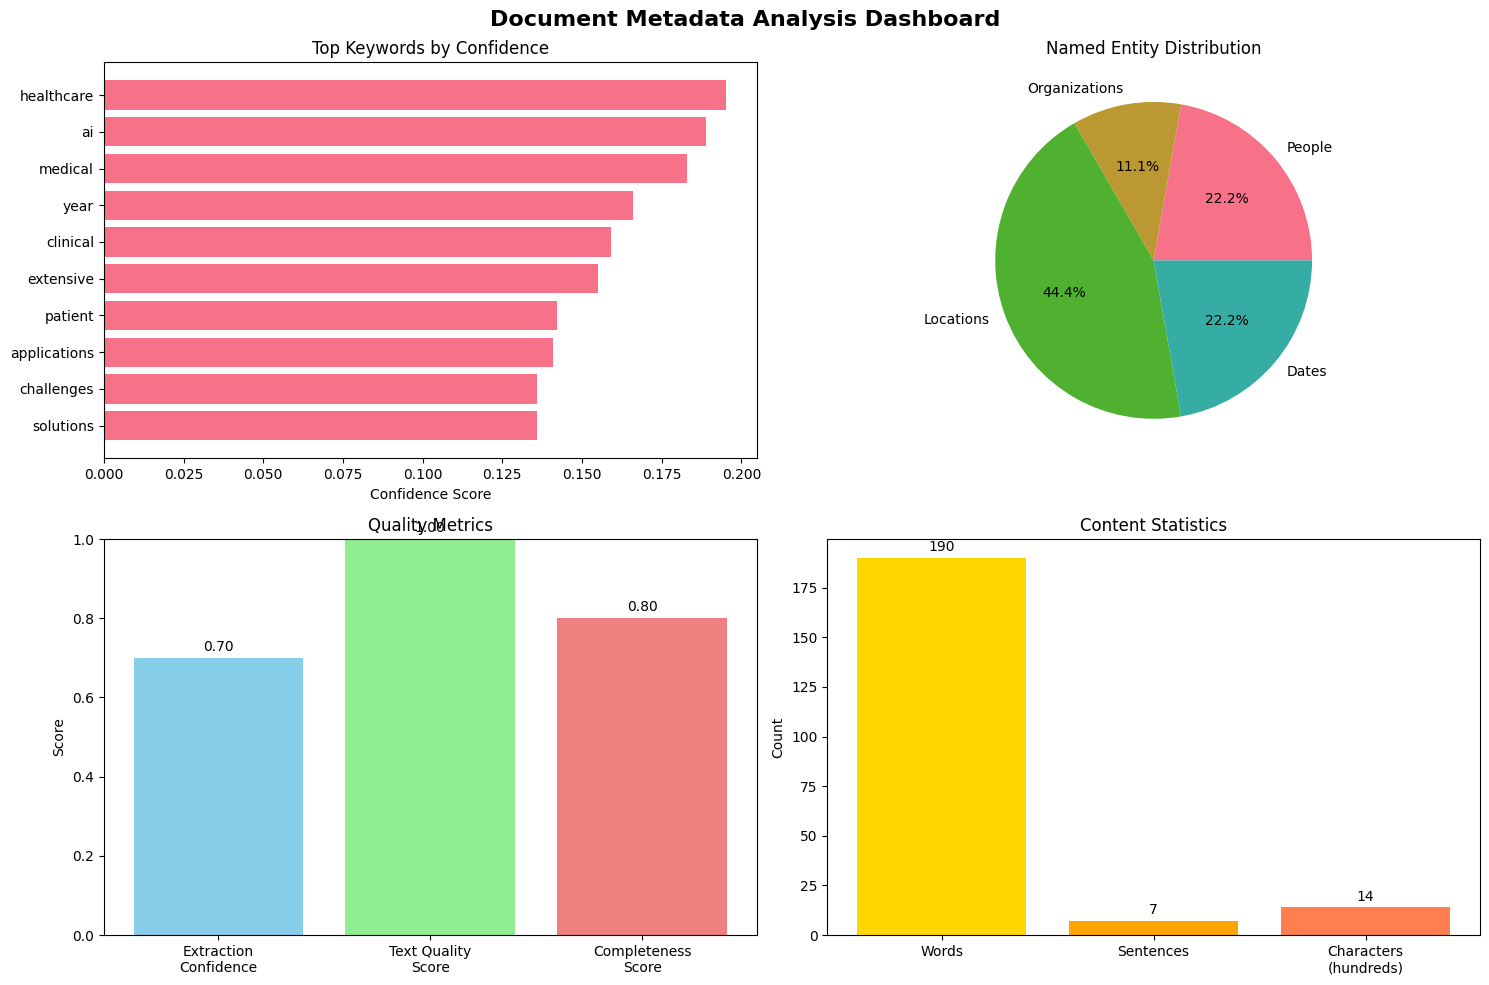


💾 JSON EXPORT PREVIEW
-------------------------
{
  "document_info": {
    "title": "Healthcare Ai Medical",
    "filename": "ai_healthcare_review.txt",
    "file_type": ".txt",
    "file_size": 0,
    "creation_date": "",
    "processing_date": "2025-06-25T06:01:00.896111"
  },
  "content_analysis": {
    "language": "en",
    "word_count": 190,
    "character_count": 1439,
    "sentence_count": 7,
    "complexity_metrics": {
      "avg_words_per_sentence": 27.14,
      "avg_chars_per_word": 6.57,
      "vocabulary_richness": 0.568,
      "c...


In [ ]:
# Example: Process a single document
def run_example_processing():
    """Run example processing with sample text"""

    sample_text = """
    Artificial Intelligence and Machine Learning in Healthcare: A Comprehensive Review

    The integration of artificial intelligence (AI) and machine learning (ML) technologies in healthcare
    has revolutionized medical diagnosis, treatment planning, and patient care. This comprehensive review
    examines the current applications, challenges, and future prospects of AI-driven healthcare solutions.

    Dr. Sarah Johnson from Stanford University Medical Center and Prof. Michael Chen from MIT have
    conducted extensive research on AI applications in radiology and pathology. Their findings,
    published in the Journal of Medical Informatics in 2023, demonstrate significant improvements
    in diagnostic accuracy.

    Key applications include:
    - Medical imaging analysis and diagnosis
    - Drug discovery and development
    - Personalized treatment recommendations
    - Clinical decision support systems
    - Predictive analytics for patient outcomes

    The technology has shown particular promise in detecting early-stage cancers, with accuracy
    rates exceeding 95% in clinical trials conducted across hospitals in Boston, New York, and
    San Francisco between January 2022 and December 2023.

    However, challenges remain in areas such as data privacy, algorithmic bias, regulatory
    compliance, and the need for extensive clinical validation. Healthcare organizations must
    address these concerns while implementing AI solutions to ensure patient safety and
    maintain public trust.
    """

    # Create mock file info
    sample_file_info = {
        'name': 'ai_healthcare_review.txt',
        'path': 'sample_document.txt',
        'extension': '.txt',
        'size': len(sample_text.encode('utf-8'))
    }

    # Save sample text to temporary file for processing
    temp_path = "sample_document.txt"
    with open(temp_path, 'w', encoding='utf-8') as f:
        f.write(sample_text)

    sample_file_info['path'] = temp_path

    # Process the document
    print("🚀 RUNNING EXAMPLE PROCESSING")
    print("=" * 50)

    metadata = process_document_pipeline(sample_file_info, save_results=False)

    if metadata:
        # Display results
        display_metadata_summary(metadata)

        # Create visualization
        create_metadata_visualization(metadata)

        # Show JSON export
        print(f"\n💾 JSON EXPORT PREVIEW")
        print("-" * 25)
        json_output = metadata_exporter.export_to_json(metadata)
        # Show first 500 characters
        print(json_output[:500] + "..." if len(json_output) > 500 else json_output)

    # Clean up
    try:
        os.remove(temp_path)
    except:
        pass

    return metadata

# Run the example
example_metadata = run_example_processing()


In [ ]:
def generate_metadata_from_file(file_path, save_results=True, visualize=True):
    """
    Process a document file and return structured metadata.

    Parameters:
    - file_path (str): Path to the document (PDF, DOCX, TXT, PNG, etc.)
    - save_results (bool): Whether to save JSON metadata output to disk
    - visualize (bool): Whether to display visualizations

    Returns:
    - metadata (dict): Extracted structured metadata
    """
    import os
    from pathlib import Path

    # Validate path
    file_path = Path(file_path)
    if not file_path.exists():
        print(f"❌ File does not exist: {file_path}")
        return None

    # Create mock file info for pipeline
    file_info = {
        'name': file_path.name,
        'path': str(file_path),
        'extension': file_path.suffix.lower(),
        'size': file_path.stat().st_size
    }

    print(f"🚀 PROCESSING FILE: {file_info['name']}")
    print("=" * 50)

    # Run your processing pipeline
    metadata = process_document_pipeline(file_info, save_results=save_results)

    if metadata:
        print("\n✅ METADATA EXTRACTION COMPLETE\n")

        if visualize:
            # Optional summaries and visualizations
            display_metadata_summary(metadata)
            create_metadata_visualization(metadata)

            print(f"\n💾 JSON EXPORT PREVIEW")
            print("-" * 25)
            json_output = metadata_exporter.export_to_json(metadata)
            print(json_output[:500] + "..." if len(json_output) > 500 else json_output)

        return metadata
    else:
        print("❌ Failed to extract metadata.")
        return None


🚀 PROCESSING FILE: The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf

🚀 PROCESSING DOCUMENT: The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf

📋 STEP 1: TEXT EXTRACTION
------------------------------

📄 Processing: The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf
🔍 File type: .pdf
🔄 Extracting text from PDF: The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf
✅ Text extracted using PyMuPDF (313597 characters)

🧹 STEP 2: TEXT PREPROCESSING
------------------------------
🔄 Preprocessing text...
✅ Preprocessing completed:
   - Word count: 59524
   - Sentence count: 3994
   - Character count: 309778

📊 STEP 3: QUALITY ASSESSMENT
------------------------------

📊 Text Quality Assessment Report
Original text length: 313,597 characters
Processed text length: 309,778 characters
Compression ratio: 98.78%
Word count: 59,524
Sentence count: 4,257
Aver

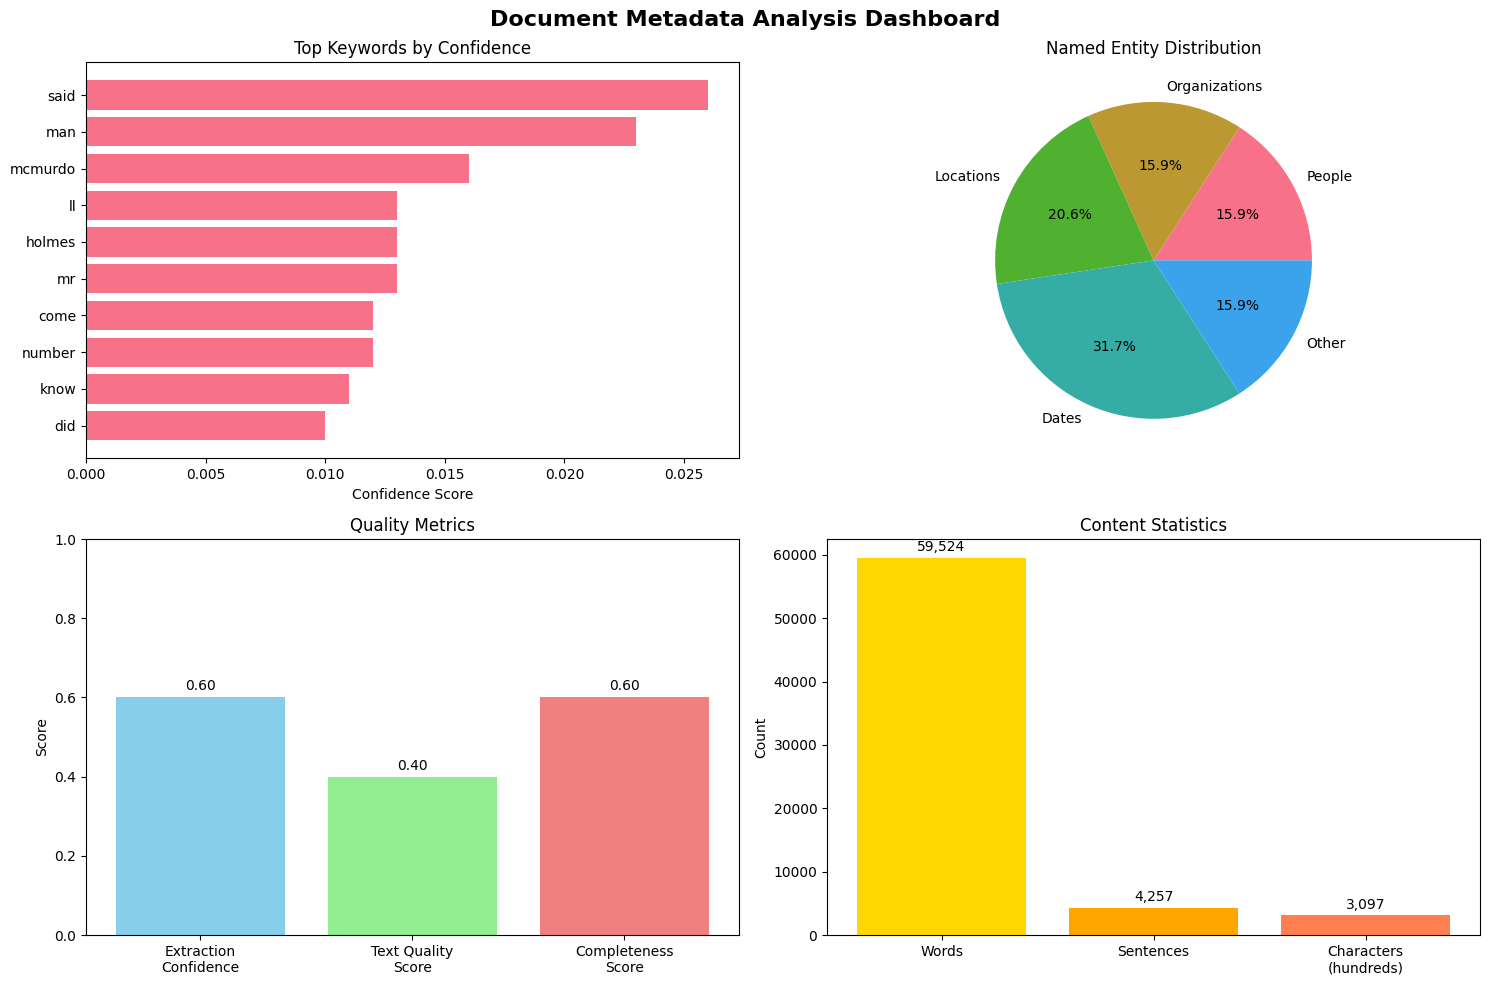


💾 JSON EXPORT PREVIEW
-------------------------
{
  "document_info": {
    "title": "Said Man Mcmurdo",
    "filename": "The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf",
    "file_type": ".pdf",
    "file_size": 0,
    "creation_date": "",
    "processing_date": "2025-06-25T07:17:44.095142"
  },
  "content_analysis": {
    "language": "en",
    "word_count": 59524,
    "character_count": 309778,
    "sentence_count": 4257,
    "complexity_metrics": {
      "avg_words_per_sentence": 13.98,
      "avg_cha...


{'document_info': {'title': 'Said Man Mcmurdo',
  'filename': 'The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf',
  'file_type': '.pdf',
  'file_size': 0,
  'creation_date': '',
  'processing_date': '2025-06-25T07:17:44.095142'},
 'content_analysis': {'language': 'en',
  'word_count': 59524,
  'character_count': 309778,
  'sentence_count': 4257,
  'complexity_metrics': {'avg_words_per_sentence': 13.98,
   'avg_chars_per_word': 4.19,
   'vocabulary_richness': 0.083,
   'complexity_level': 'low',
   'total_words': 59524,
   'total_sentences': 4257,
   'unique_words': 4929}},
 'semantic_metadata': {'keywords': ['said',
   'man',
   'mcmurdo',
   'll',
   'holmes',
   'mr',
   'come',
   'number',
   'know',
   'did',
   'cried',
   'say',
   'house',
   'time',
   'good'],
  'keyword_details': [{'keyword': 'said',
    'confidence': np.float64(0.026),
    'length': 1},
   {'keyword': 'man', 'confidence': np.float64(0.023), 'length': 1},
   {'keyword': 

In [ ]:
generate_metadata_from_file("/content/The Valley of Fear (Sherlock Homes - Novel 4) (Sir Arthur Conan Doyle) (Z-Library).pdf")

In [ ]:
# prompt: i want to deploy given file using streamlit
# this function in given python file gives the final result "generate_metadata_from_file(file_path, save_results=True, visualize=True)" which i want to show on my user interface
# here are myy requirements-
# 1. a button to upload a file on which my python, generate_metadata_from_file(file_path, save_results=True, visualize=True) this function will run for result
# 2. a button to process the file clicking on which t will start running the function
# also i want to export the json file generated so give a download button for that too

import streamlit as st
import json
from pathlib import Path
import os

# Assuming the rest of your processing code is in this file or imported

# --- Streamlit App Interface ---

st.title("Document Metadata Extractor")
st.markdown("Upload a document (PDF, DOCX, TXT, JPG, PNG) to extract its metadata.")

uploaded_file = st.file_uploader("Choose a file...", type=['pdf', 'docx', 'txt', 'jpg', 'jpeg', 'png'])

if uploaded_file is not None:
    # Save the uploaded file temporarily
    temp_dir = Path(tempfile.gettempdir())
    file_path = temp_dir / uploaded_file.name
    with open(file_path, "wb") as f:
        f.write(uploaded_file.getbuffer())

    st.write(f"File uploaded: {uploaded_file.name}")

    process_button = st.button("Process Document")

    if process_button:
        st.info("Processing document... This may take a few moments.")

        # Run your existing function
        # Assuming generate_metadata_from_file handles the file path correctly
        metadata = generate_metadata_from_file(str(file_path), save_results=False, visualize=False) # Don't save or visualize within the function call for Streamlit

        if metadata:
            st.success("Processing Complete!")

            # Display metadata summary
            st.subheader("Extracted Metadata Summary")
            st.json(metadata) # Display the full metadata dictionary

            # Create download button for JSON
            json_output = metadata_exporter.export_to_json(metadata, pretty_print=True)
            st.download_button(
                label="Download Metadata (JSON)",
                data=json_output,
                file_name=f"metadata_{Path(uploaded_file.name).stem}.json",
                mime="application/json"
            )

            # Optional: Display visualizations
            st.subheader("Metadata Visualizations")
            # Need to adapt your visualization function to work with Streamlit
            # This is a placeholder - you would need to modify create_metadata_visualization
            # to return Streamlit-compatible chart objects (e.g., using st.pyplot or st.plotly_chart)
            # For simplicity, we will just show a message.
            # If you want charts, you'd need to refactor the plotting part.
            st.write("Visualizations would be displayed here (requires adapting plotting code for Streamlit).")


        else:
            st.error("Failed to extract metadata from the document.")

        # Clean up the temporary file
        try:
            os.remove(file_path)
        except Exception as e:
            st.warning(f"Could not remove temporary file: {e}")

